In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Paths
emdat_data = "/mnt/team/rapidresponse/pub/flooding/data/emdat/public_emdat_custom_request_2024-04-15.csv"

In [3]:
### Load emdat data
emdat_df = pd.read_csv(emdat_data)

In [9]:
emdat_df['Admin Units'].unique()

<ArrowStringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                nan,
                                                                                                                                                                                                                                                                                                                                                               

In [4]:
emdat_df['Location'].unique()

<ArrowStringArray>
[                                                                                                                                                                                                                                                                                               'Galveston (Texas)',
                                                                                                                                                                                                                                                                                                      'Saint James',
                                                                                                                                                                                                                                                                                                            'Porus',
                                                      

In [10]:
emdat_df['Location'].contains('Bangladesh')

AttributeError: 'Series' object has no attribute 'contains'

In [6]:

# subset to Disater Type: Storm
emdat_df = emdat_df[emdat_df['Disaster Type'] == 'Storm']

In [14]:
emdat_df.columns

Index(['DisNo.', 'Historic', 'Classification Key', 'Disaster Group',
       'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype',
       'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region',
       'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal',
       'Declaration', 'AID Contribution ('000 US$)', 'Magnitude',
       'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year',
       'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day',
       'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless',
       'Total Affected', 'Reconstruction Costs ('000 US$)',
       'Reconstruction Costs, Adjusted ('000 US$)',
       'Insured Damage ('000 US$)', 'Insured Damage, Adjusted ('000 US$)',
       'Total Damage ('000 US$)', 'Total Damage, Adjusted ('000 US$)', 'CPI',
       'Admin Units', 'Entry Date', 'Last Update'],
      dtype='str')

In [6]:
emdat_df[(emdat_df['ISO'] == 'IND') & ((emdat_df['Start Year'] == 2011) | (emdat_df['End Year'] == 2011))][['DisNo.', 'Historic', 'Classification Key', 'Disaster Group',
       'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype',
       'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region',
       'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal',
       'Declaration', 'Magnitude',
       'Start Year',
       'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day',
       'Total Deaths', 
       'Admin Units', 'Entry Date', 'Last Update']]

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,Start Year,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,Admin Units,Entry Date,Last Update
11962,2011-0007-IND,No,nat-met-ext-col,Natural,Meteorological,Extreme temperature,Cold wave,NaN,NaN,IND,...,2011,1.0,1.0,2011,1.0,18.0,80.0,"[{""adm1_code"":1489,""adm1_name"":""Delhi""},{""adm1...",2012-04-05,2023-09-25
12039,2011-0176-IND,No,nat-met-sto-lig,Natural,Meteorological,Storm,Lightning/Thunderstorms,NaN,NaN,IND,...,2011,5.0,20.0,2011,5.0,20.0,42.0,"[{""adm1_code"":70081,""adm1_name"":""Uttar Pradesh""}]",2011-05-24,2023-09-25
12118,2011-0327-IND,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,IND,...,2011,8.0,10.0,2011,9.0,13.0,47.0,"[{""adm1_code"":1511,""adm1_name"":""West Bengal""}]",2011-11-07,2023-09-25
12139,2011-0351-IND,No,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,GLIDE:EQ-2011-000136|USGS:usp000j88b,NaN,IND,...,2011,9.0,18.0,2011,9.0,18.0,112.0,"[{""adm1_code"":1487,""adm1_name"":""Assam""},{""adm1...",2011-11-07,2023-09-25
12149,2011-0371-IND,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,GLIDE:FL-2011-000138,NaN,IND,...,2011,9.0,23.0,2011,10.0,23.0,239.0,"[{""adm2_code"":17809,""adm2_name"":""Cuttack""},{""a...",2014-07-28,2023-09-25
12184,2011-0422-IND,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,IND,...,2011,8.0,15.0,2011,9.0,8.0,7.0,"[{""adm2_code"":70087,""adm2_name"":""Dhemaji""},{""a...",2011-11-07,2023-09-25
12186,2011-0424-IND,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,IND,...,2011,8.0,15.0,2011,10.0,2.0,204.0,"[{""adm2_code"":17576,""adm2_name"":""Barpeta""},{""a...",2011-11-14,2023-09-25
12190,2011-0428-IND,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,IND,...,2011,7.0,23.0,2011,8.0,9.0,19.0,"[{""adm1_code"":1506,""adm1_name"":""Rajasthan""},{""...",2011-11-07,2023-09-25
12208,2011-0473-IND,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,IND,...,2011,9.0,5.0,2011,9.0,15.0,42.0,"[{""adm1_code"":1504,""adm1_name"":""Orissa""}]",2012-01-03,2023-09-25
12244,2011-0566-IND,No,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,NaN,Cyclone Thane,IND,...,2011,12.0,29.0,2011,12.0,30.0,47.0,"[{""adm2_code"":70243,""adm2_name"":""Cuddalore""},{...",2012-04-04,2023-09-25


In [3]:
from pathlib import Path
SOURCE_CSV = Path(
    "/mnt/team/rapidresponse/pub/tropical-storms/data/ibtracs_deaths/"
    "combined_ibtracs_with_deaths_deduplicated_with_sdi_updated_island.csv"
)
df = pd.read_csv(SOURCE_CSV)
# mask = (
#     (df["level"] == FILTER_LEVEL)
#     & (df["year"] <= FILTER_MAX_YEAR)
#     & (df["exposed_population"] >= FILTER_MIN_EXPOSED)
# )
# df = df.loc[mask].copy()
print(f"  After filters: {len(df):,} rows")

# --- Recode basin: NaN (empty string in CSV) -> 'NA' ---
# The CSV stores North Atlantic as empty string ''; with na_values=['']
# these arrive as NaN. We recode to the canonical 'NA' code.
n_missing_basin = df["basin"].isna().sum()
if n_missing_basin:
    df["basin"] = df["basin"].fillna("NA")
    print(f"  Recoded {n_missing_basin:,} missing basin values -> 'NA'")
else:
    print("  No missing basin values.")

  After filters: 9,545 rows
  Recoded 1,456 missing basin values -> 'NA'


In [7]:
df['level'].unique()

array([3., 4., 5.])

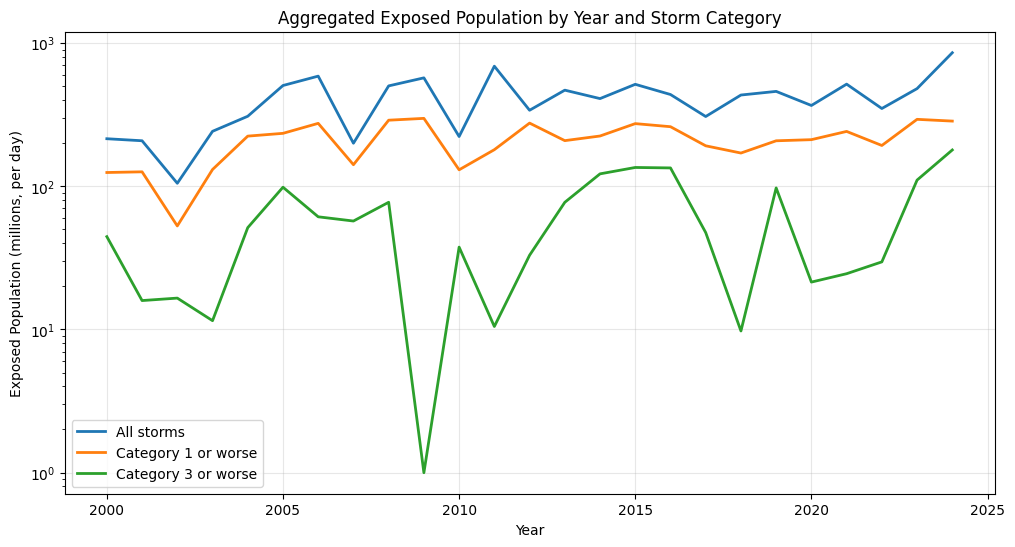

In [5]:
df['exposed_per_day'] = df['exposed_population'] / 24
df = df[df['year'] >= 2000]

# Aggregate exposed_per_day by year and storm_category
agg_by_year = df.groupby('year')['exposed_per_day'].sum() / 1e6  # Convert to millions

# Define categories for different thresholds
cat_1_or_worse = ['Category 1', 'Category 2', 'Category 3', 'Category 4', 'Category 5']
cat_3_or_worse = ['Category 3', 'Category 4', 'Category 5']

# All storms
all_storms = df.groupby('year')['exposed_per_day'].sum() / 1e6

# Category 1 or worse
cat_1_df = df[df['storm_category'].isin(cat_1_or_worse)]
cat_1_storms = cat_1_df.groupby('year')['exposed_per_day'].sum() / 1e6

# Category 3 or worse
cat_3_df = df[df['storm_category'].isin(cat_3_or_worse)]
cat_3_storms = cat_3_df.groupby('year')['exposed_per_day'].sum() / 1e6

# Plot
plt.figure(figsize=(12, 6))
plt.plot(all_storms.index, all_storms.values, label='All storms', linewidth=2)
plt.plot(cat_1_storms.index, cat_1_storms.values, label='Category 1 or worse', linewidth=2)
plt.plot(cat_3_storms.index, cat_3_storms.values, label='Category 3 or worse', linewidth=2)

plt.xlabel('Year')
plt.ylabel('Exposed Population (millions, per day)')
plt.title('Aggregated Exposed Population by Year and Storm Category')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


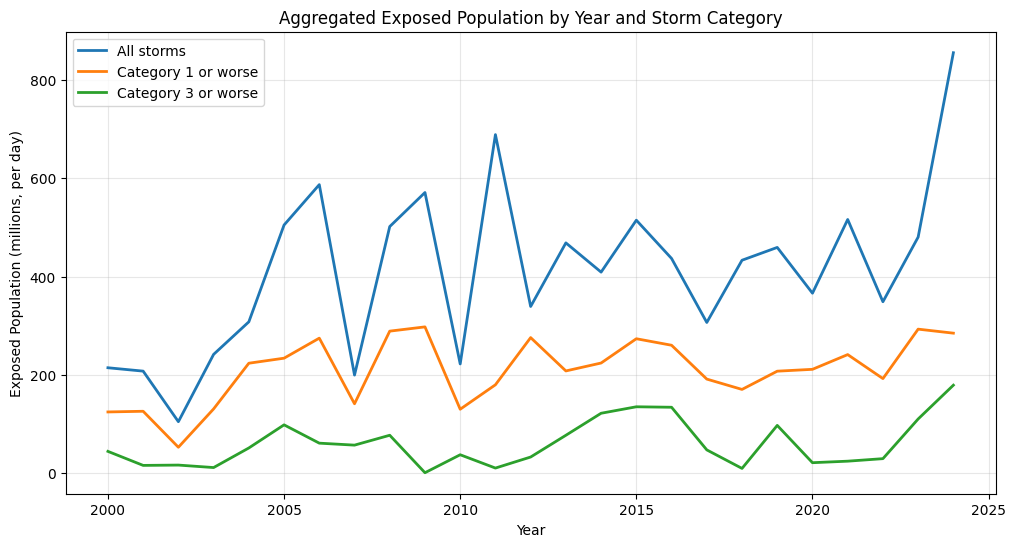

In [6]:
df['exposed_per_day'] = df['exposed_population'] / 24
df = df[df['year'] >= 2000]

# Aggregate exposed_per_day by year and storm_category
agg_by_year = df.groupby('year')['exposed_per_day'].sum() / 1e6  # Convert to millions

# Define categories for different thresholds
cat_1_or_worse = ['Category 1', 'Category 2', 'Category 3', 'Category 4', 'Category 5']
cat_3_or_worse = ['Category 3', 'Category 4', 'Category 5']

# All storms
all_storms = df.groupby('year')['exposed_per_day'].sum() / 1e6

# Category 1 or worse
cat_1_df = df[df['storm_category'].isin(cat_1_or_worse)]
cat_1_storms = cat_1_df.groupby('year')['exposed_per_day'].sum() / 1e6

# Category 3 or worse
cat_3_df = df[df['storm_category'].isin(cat_3_or_worse)]
cat_3_storms = cat_3_df.groupby('year')['exposed_per_day'].sum() / 1e6

# Plot
plt.figure(figsize=(12, 6))
plt.plot(all_storms.index, all_storms.values, label='All storms', linewidth=2)
plt.plot(cat_1_storms.index, cat_1_storms.values, label='Category 1 or worse', linewidth=2)
plt.plot(cat_3_storms.index, cat_3_storms.values, label='Category 3 or worse', linewidth=2)

plt.xlabel('Year')
plt.ylabel('Exposed Population (millions, per day)')
plt.title('Aggregated Exposed Population by Year and Storm Category')
# plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


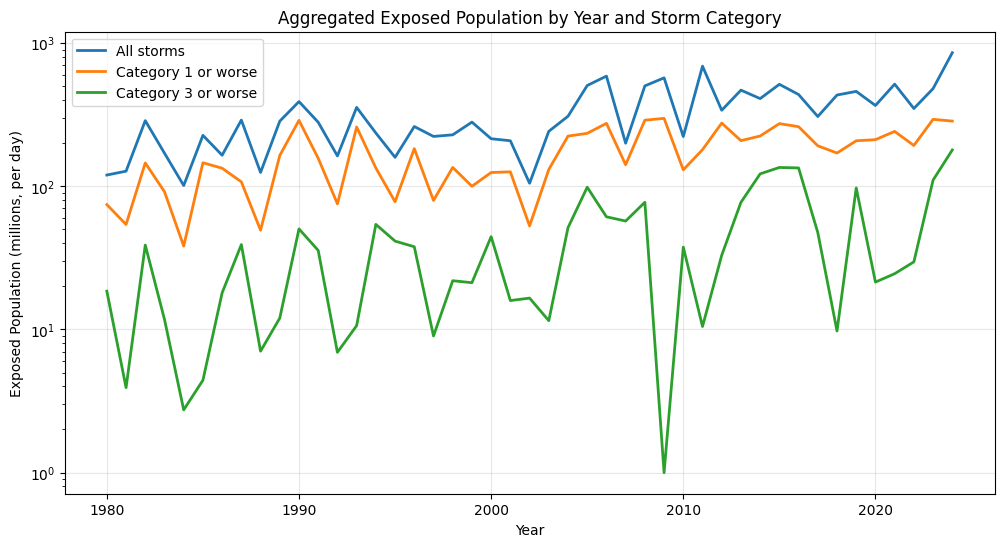

In [85]:
df_level_3 = df[df['level'] >= 3].copy()

# Aggregate exposed_per_day by year and storm_category
agg_by_year = df_level_3.groupby('year')['exposed_per_day'].sum() / 1e6  # Convert to millions

# Define categories for different thresholds
cat_1_or_worse = ['Category 1', 'Category 2', 'Category 3', 'Category 4', 'Category 5']
cat_3_or_worse = ['Category 3', 'Category 4', 'Category 5']

# All storms
all_storms = df_level_3.groupby('year')['exposed_per_day'].sum() / 1e6

# Category 1 or worse
cat_1_df = df_level_3[df_level_3['storm_category'].isin(cat_1_or_worse)]
cat_1_storms = cat_1_df.groupby('year')['exposed_per_day'].sum() / 1e6

# Category 3 or worse
cat_3_df = df_level_3[df_level_3['storm_category'].isin(cat_3_or_worse)]
cat_3_storms = cat_3_df.groupby('year')['exposed_per_day'].sum() / 1e6

# Plot
plt.figure(figsize=(12, 6))
plt.plot(all_storms.index, all_storms.values, label='All storms', linewidth=2)
plt.plot(cat_1_storms.index, cat_1_storms.values, label='Category 1 or worse', linewidth=2)
plt.plot(cat_3_storms.index, cat_3_storms.values, label='Category 3 or worse', linewidth=2)

plt.xlabel('Year')
plt.ylabel('Exposed Population (millions, per day)')
plt.title('Aggregated Exposed Population by Year and Storm Category')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [79]:
df['exp_per_capita'] = (df['exposed_population'] / df['pop_total'])
df['exp_per_capita'].describe()

count    9545.000000
mean        5.546666
std         7.298410
min         0.000000
25%         0.467968
50%         2.547389
75%         8.562447
max       115.807214
Name: exp_per_capita, dtype: float64

In [78]:
wtf_df = df[df['exp_per_capita'] > 4].copy()
wtf_df[['storm_id', 'year', 'start_date_x', 'end_date_x',
       'location_id', 'max_wind_speed', 'pop_total', 'exposed_population',
       'total_deaths', 'data_year', 'basin', 'sdi', 'ln_total_deaths',
       'parent_id','level',
       'location_name',
       'ihme_loc_id',
       'is_island', 
       'storm_category', 'log_exposed_population']]

,storm_id,year,start_date_x,end_date_x,location_id,max_wind_speed,pop_total,exposed_population,total_deaths,data_year,basin,sdi,ln_total_deaths,parent_id,level,location_name,ihme_loc_id,is_island,storm_category,log_exposed_population
1876,1986228N19120,1986,1986-08-18,1986-09-06,53547,39.277035,5548.8516,642597.045121,0,1986,WP,NaN,-13.815511,16.0,4.0,Batanes,PHL_53547,1.0,Category 1,13.373275


In [73]:
big_exp = df[df['exposed_population'] > 2_000_000_000].copy()

In [43]:
big_exp.columns

Index(['Unnamed: 0', 'storm_id', 'year', 'start_date_x', 'end_date_x',
       'location_id', 'max_wind_speed', 'pop_total', 'exposed_population',
       'total_deaths', 'data_year', 'basin', 'sdi', 'ln_total_deaths',
       'deaths_rate', 'ln_death_rate', 'ln_death_rate_pop_weighted',
       'exists_deaths', 'ln_exists_deaths', 'location_set_version_id',
       'location_set_id', 'parent_id', 'path_to_top_parent', 'level',
       'is_estimate', 'most_detailed', 'sort_order', 'location_name',
       'location_ascii_name', 'location_name_short', 'location_name_medium',
       'location_type_id', 'location_type', 'map_id', 'super_region_id',
       'super_region_name', 'region_id', 'region_name', 'ihme_loc_id',
       'local_id', 'developed', 'start_date_y', 'end_date_y', 'date_inserted',
       'last_updated', 'last_updated_by', 'last_updated_action',
       'lancet_label', 'who_label', 'is_island', 'sdi_ln', 'wind_mph',
       'storm_category', 'log_exposed_population'],
      dtype='st

In [54]:
df[df['storm_id'] == '2011167N22089']

,Unnamed: 0,storm_id,year,start_date_x,end_date_x,location_id,max_wind_speed,pop_total,exposed_population,total_deaths,...,last_updated,last_updated_by,last_updated_action,lancet_label,who_label,is_island,sdi_ln,wind_mph,storm_category,log_exposed_population
7334,7334,2011167N22089,2011,2011-06-16,2011-06-22,4844,24.072541,174699200.0,1.213888e+08,0,...,2026-01-07 12:37:30,cathc19,INSERT,Bihar,NaN,0.0,-1.034984,53.850273,Tropical Storm,18.614509
7367,7367,2011167N22089,2011,2011-06-16,2011-06-22,4846,24.673973,56716150.0,6.908050e+07,0,...,2026-01-07 12:37:30,cathc19,INSERT,Chhattisgarh,NaN,0.0,-0.949031,55.195678,Tropical Storm,18.050783
7416,7416,2011167N22089,2011,2011-06-16,2011-06-22,4855,27.650182,99427330.0,2.074154e+09,0,...,2026-01-07 12:37:30,cathc19,INSERT,Jharkhand,NaN,0.0,-0.934865,61.853457,Tropical Storm,21.452819
7458,7458,2011167N22089,2011,2011-06-16,2011-06-22,4859,21.802992,195799780.0,2.643527e+08,0,...,2026-01-07 12:37:30,cathc19,INSERT,Madhya Pradesh,NaN,0.0,-0.974818,48.773294,Tropical Storm,19.392795
7516,7516,2011167N22089,2011,2011-06-16,2011-06-22,4865,22.776374,70826190.0,1.880561e+08,0,...,2026-01-07 12:37:30,cathc19,INSERT,Odisha,NaN,0.0,-0.875449,50.950749,Tropical Storm,19.052251
7552,7552,2011167N22089,2011,2011-06-16,2011-06-22,4873,24.673973,297529470.0,4.257985e+08,0,...,2026-01-07 12:37:30,cathc19,INSERT,Uttar Pradesh,NaN,0.0,-0.912267,55.195678,Tropical Storm,19.869477
7594,7594,2011167N22089,2011,2011-06-16,2011-06-22,4875,31.279330,237536640.0,3.978523e+09,0,...,2026-01-07 12:37:30,cathc19,INSERT,West Bengal,NaN,0.0,-0.853014,69.971862,Tropical Storm,22.104177
8658,8658,2011167N22089,2011,2011-06-16,2011-06-22,161,31.279330,223385950.0,2.300281e+09,0,...,2026-01-07 12:37:30,cathc19,INSERT,Bangladesh,People’s Republic of Bangladesh,0.0,-0.988383,69.971862,Tropical Storm,21.556297


In [74]:
big_exp[['storm_id', 'year', 'start_date_x', 'end_date_x',
       'location_id', 'max_wind_speed', 'pop_total', 'exposed_population',
       'total_deaths', 'data_year', 'basin', 'sdi', 'ln_total_deaths',
       'parent_id','level',
       'location_name',
       'ihme_loc_id',
       'is_island', 
       'storm_category', 'log_exposed_population']].sort_values('total_deaths', ascending=False)

,storm_id,year,start_date_x,end_date_x,location_id,max_wind_speed,pop_total,exposed_population,total_deaths,data_year,basin,sdi,ln_total_deaths,parent_id,level,location_name,ihme_loc_id,is_island,storm_category,log_exposed_population
7416,2011167N22089,2011,2011-06-16,2011-06-22,4855,27.650182,99427330.0,2.074154e+09,0,2011,NI,0.392639,-13.815511,163.0,4.0,Jharkhand,IND_4855,0.0,Tropical Storm,21.452819
7594,2011167N22089,2011,2011-06-16,2011-06-22,4875,31.279330,237536640.0,3.978523e+09,0,2011,NI,0.426129,-13.815511,163.0,4.0,West Bengal,IND_4875,0.0,Tropical Storm,22.104177
7617,2024258N22091,2024,2024-09-13,2024-09-17,4875,23.305540,266077600.0,2.185152e+09,0,2024,NI,NaN,-13.815511,163.0,4.0,West Bengal,IND_4875,0.0,Tropical Storm,21.504951
8658,2011167N22089,2011,2011-06-16,2011-06-22,161,31.279330,223385950.0,2.300281e+09,0,2011,NI,0.372178,-13.815511,159.0,3.0,Bangladesh,BGD,0.0,Tropical Storm,21.556297


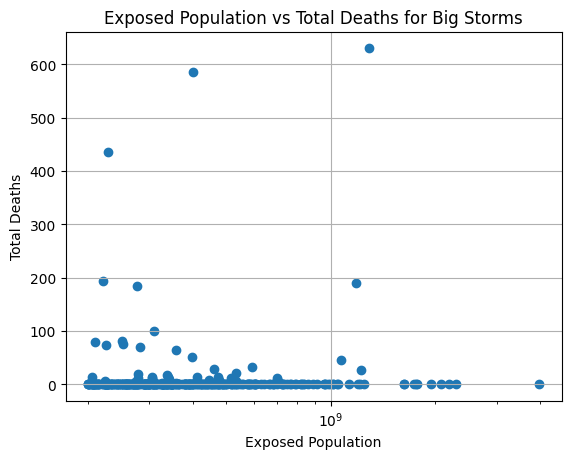

In [69]:
# plot big_exp exposed population against deaths
plt.scatter(big_exp['exposed_population'], big_exp['total_deaths'])
plt.xscale('log')

plt.xlabel('Exposed Population')
plt.ylabel('Total Deaths')
plt.title('Exposed Population vs Total Deaths for Big Storms')
plt.grid(True)
plt.show()

In [61]:
big_exp['exp_per_capita'] = (big_exp['exposed_population'] / big_exp['pop_total']) / 24
big_exp['exp_per_capita'].describe()

count    352.000000
mean       0.261267
std        0.272210
min        0.005736
25%        0.108287
50%        0.180310
75%        0.300412
max        2.069928
Name: exp_per_capita, dtype: float64

In [32]:
big_exp['level']

926     4.0
1016    4.0
1030    4.0
1287    4.0
1290    4.0
       ... 
9089    4.0
9109    4.0
9278    3.0
9279    3.0
9437    3.0
Name: level, Length: 806, dtype: float64

In [12]:
emdat_df[emdat_df["Location"].str.contains("Bangladesh", case=False, na=False)]

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,Entry Date,Last Update
5213,1994-0087-BGD,Yes,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,NaN,NaN,BGD,...,NaN,NaN,NaN,NaN,2500.0,4936.0,50.648403,NaN,2003-07-01,2023-09-25


In [ ]:

# Filter out rows with missing values in start year or end year
emdat_df = emdat_df.dropna(subset=['Start Year', 'End Year'])
# For any row with a missing value for start month, start day, end month or end day, set them to 1
emdat_df['Start Month'] = emdat_df['Start Month'].fillna(1).astype(int)
emdat_df['Start Day'] = emdat_df['Start Day'].fillna(1).astype(int)
emdat_df['End Month'] = emdat_df['End Month'].fillna(1).astype(int)
emdat_df['End Day'] = emdat_df['End Day'].fillna(1).astype(int)
# Create a start date column using start year, start month and start day
emdat_df['start_date'] = pd.to_datetime(emdat_df[['Start Year', 'Start Month', 'Start Day']].astype(str).agg('-'.join, axis=1), errors='coerce')
# Create an end date column using end year, end month and end day
emdat_df['end_date'] = pd.to_datetime(emdat_df[['End Year', 'End Month', 'End Day']].astype(str).agg('-'.join, axis=1), errors='coerce')
# Extract the year from start date
emdat_df['year'] = emdat_df['start_date'].dt.year
# Keep only the data from 1970 to present
emdat_df = emdat_df[(emdat_df['year'] >= 1970) & (emdat_df['year'] <= 2024)]
# Create a new column in gbd_df called ISO and set it to the local_id
gbd_df['ISO'] = gbd_df['local_id']
# Merge emdat_df with gbd_df on the 'ISO' column
emdat_df = emdat_df.merge(gbd_df[['ISO', 'location_id']], left_on='ISO', right_on='ISO', how='left')
# Manual fixes for missing location_id
# Hong Kong
emdat_df.loc[emdat_df['Country'] == 'China, Hong Kong Special Administrative Region', 'location_id'] = 354
emdat_df.loc[emdat_df['Country'] == 'China, Hong Kong Special Administrative Region', 'ISO'] = 'CN-91'
# Yemen
emdat_df.loc[emdat_df['Country'] == "People's Democratic Republic of Yemen", 'location_id'] = 157
emdat_df.loc[emdat_df['Country'] == "People's Democratic Republic of Yemen", 'ISO'] = 'YEM'
emdat_df.loc[emdat_df['Country'] == "Yemen Arab Republic", 'location_id'] = 157
emdat_df.loc[emdat_df['Country'] == "Yemen Arab Republic", 'ISO'] = 'YEM'
# subset to rows that have missing location_id
missing_df = emdat_df[emdat_df['location_id'].isnull()]


In [ ]:
# which gbd_df['location_name'] is 'like' Hong Kong
# gbd_df[gbd_df['location_name'].str.contains('Fr', na=False)]
# print(missing_df['Country'].unique())
# print(len(missing_df['Country'].unique()))
# print(len(missing_df['Country']))
# missing_df

,location_set_version_id,location_set_id,location_id,parent_id,path_to_top_parent,level,is_estimate,most_detailed,sort_order,location_name,...,developed,start_date,end_date,date_inserted,last_updated,last_updated_by,last_updated_action,lancet_label,who_label,ISO
260,1121,35,80,73,"1,64,73,80",3,1,1,261.0,France,...,1.0,2022-07-22 11:59:04,NaN,2022-07-22 11:59:04,2022-07-22 11:59:04,cathc19,INSERT,France,French Republic,FRA
272,1121,35,35501,86,"1,64,73,86,35501",4,1,1,273.0,Friuli-Venezia Giulia,...,1.0,2022-07-22 11:59:04,NaN,2022-07-22 11:59:04,2022-07-22 11:59:04,cathc19,INSERT,Friuli-Venezia Giulia,NaN,IT-36
1009,1121,35,483,196,"1,166,192,196,483",4,1,1,1010.0,Free State,...,0.0,2022-07-22 11:59:04,NaN,2022-07-22 11:59:04,2022-07-22 11:59:04,cathc19,INSERT,Free State,NaN,ZA-FS


In [8]:
# Write out the matched emdat_df to a csv file
emdat_df.to_csv('/mnt/team/rapidresponse/pub/flooding/data/emdat/emdat_matched.csv', index=False)